In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm import trange
import ot

In [2]:
torch.manual_seed(0)
np.random.seed(0)

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 512, bias=False)
        self.fc2 = nn.Linear(512, 10, bias=False)
        self.relu = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 28*28)
        h = self.relu(self.fc1(x))
        out = self.fc2(h)
        return self.logsoftmax(out)

In [4]:
transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=512)

In [6]:
def train_model(model, dataset, epochs=5, lr=1e-1, batch_size=128, seed = 0,verbose=True):
    torchseed = torch.manual_seed(seed)
    npseed = np.random.seed(seed)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum = 0, dampening = 0 , weight_decay = 0)
    criterion = nn.NLLLoss()
    model.train()
    for epoch in range(epochs):
        running = 0.0
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - loss: {running/len(loader.dataset):.4f}")
    return model

In [8]:
print("Training Model A on subset A...")
modelA = train_model(MLP(), dataset, seed = 0)
print("Training Model B on subset B...")
modelB = train_model(MLP(), dataset, seed = 1)
#print("Training Full Model on full training dataset")
#modelFull = train_model(MLP(), dataset)


stateA = modelA.state_dict()
stateB = modelB.state_dict()
#modelFull_state = modelFull.state_dict()


# torch.save(modelA.state_dict(), "modelA.pt")
# torch.save(modelB.state_dict(), "modelB.pt")
# torch.save(modelFull.state_dict(), "modelFull.pt")
# print("Saved modelA.pt, modelB.pt, and modelFull.pt")

Training Model A on subset A...
Epoch 1/5 - loss: 0.5543
Epoch 2/5 - loss: 0.2822
Epoch 3/5 - loss: 0.2281
Epoch 4/5 - loss: 0.1910
Epoch 5/5 - loss: 0.1635
Training Model B on subset B...
Epoch 1/5 - loss: 0.5577
Epoch 2/5 - loss: 0.2847
Epoch 3/5 - loss: 0.2283
Epoch 4/5 - loss: 0.1907
Epoch 5/5 - loss: 0.1636


In [9]:
def evaluate_model_state_dict(state_dict, model_cls=MLP):
    m = model_cls()
    m.load_state_dict(state_dict)
    m.eval()

    criterion = torch.nn.NLLLoss(reduction='sum')  # sum first, then average
    total_loss = 0.0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            out = m(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            total += y.size(0)

    return total_loss / total

LossA = evaluate_model_state_dict(stateA)
LossB = evaluate_model_state_dict(stateB)


print("Eval Model A:", LossA )
print("Eval Model B:", LossB)

Eval Model A: 0.15139550552368164
Eval Model B: 0.15529072036743163


In [10]:
def interp_states(state1, state2, lam):
    out = {}
    for k in state1.keys():
        out[k] = (1 - lam) * state1[k].float() + lam * state2[k].float()
    return out

lambdas = np.linspace(0, 1, 21)
merged_naive_loss = []
for lam in lambdas:
    s = interp_states(stateA, stateB, lam)
    merged_naive_loss.append(evaluate_model_state_dict(s))

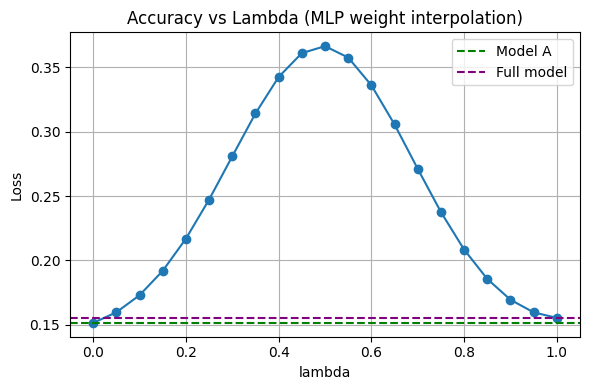

In [11]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, merged_naive_loss, marker='o')
plt.axhline(LossA, color='green', linestyle='--', label="Model A")
plt.axhline(LossB, color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

In [13]:
### This will take in the weights in tensors, make them arrays
def compute_similarity(W_A, W_B):
    A = np.asarray(W_A)
    B = np.asarray(W_B)
    return A @ B.T


def match_neurons_1layer(WA, WB):
    """
    One-hidden-layer neuron matching.

    WA, WB: numpy arrays of shape (h, d)
            rows = neuron weight vectors

    Returns:
        P : permutation matrix (h x h)
    """
    # Compute neuron-to-neuron similarity matrix
    # S[i,j] = <w_i^A, w_j^B>
    S = WA@WB.T

    # Solve linear assignment (maximize similarity)
    cost = -S
    row_ind, col_ind = linear_sum_assignment(cost)

    h = WA.shape[0]
    P = np.zeros((h, h), dtype=np.float32)
    P[row_ind, col_ind] = 1.0

    return P

WA = np.asarray(stateA['fc1.weight'])
WB = np.asarray(stateB['fc1.weight'])

P = match_neurons_1layer(WA, WB)

In [14]:
# Get original state_dict of model B
stateB = modelB.state_dict()

# --- Permute fc1.weight (rows) ---
W1_B = stateB['fc1.weight'].numpy()      # (512, 784)
W1_B_perm = P @ W1_B                            # permute rows

# --- Permute fc2.weight (columns) ---
W2_B = stateB['fc2.weight'].numpy()      # (10, 512)
W2_B_perm = W2_B @ P.T                          # permute columns

# --- Build new state_dict ---
stateB_perm = {}

for k, v in stateB.items():
    if k == 'fc1.weight':
        stateB_perm[k] = torch.from_numpy(W1_B_perm).float()
    elif k == 'fc2.weight':
        stateB_perm[k] = torch.from_numpy(W2_B_perm).float()
    else:
        # copy everything else unchanged (biases if they exist)
        stateB_perm[k] = v.clone()

In [16]:
modelB_perm = MLP()
modelB_perm.load_state_dict(stateB_perm)

lambdas = np.linspace(0, 1, 21)
merged_permuted_loss = []
for lam in lambdas:
    s2 = interp_states(stateA, stateB_perm, lam)
    merged_permuted_loss.append(evaluate_model_state_dict(s2))

In [17]:
### Loss Barriers
naive_loss_barrier = max(merged_naive_loss) - 0.5 * (LossA + LossB)
permuted_loss_barrier = max(merged_permuted_loss) - 0.5 * (LossA + LossB)

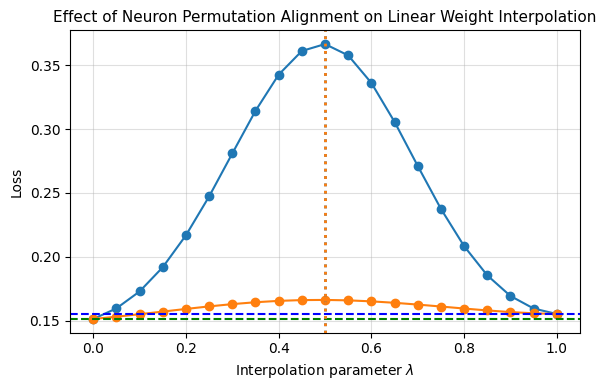

In [18]:
plt.figure(figsize=(6,4))

lambda_naive_barrier = lambdas[np.argmax(merged_naive_loss)]
lambda_perm_barrier  = lambdas[np.argmax(merged_permuted_loss)]

plt.plot(lambdas, merged_naive_loss,marker='o', label='Naive interpolation')

plt.plot(lambdas, merged_permuted_loss,marker='o', label='Permutation-aligned interpolation')

plt.axhline(LossA,color='green', linestyle='--', linewidth=1.5, label='Model A')

plt.axhline(LossB,color='blue', linestyle='--', linewidth=1.5, label='Model B')


plt.axvline(lambda_naive_barrier, color='tab:blue', linestyle=':',
            linewidth=2, label='Naive loss barrier')

plt.axvline(lambda_perm_barrier, color='tab:orange', linestyle=':',
            linewidth=2, label='Permuted loss barrier')

plt.title('Effect of Neuron Permutation Alignment on Linear Weight Interpolation',fontsize=11)

plt.xlabel('Interpolation parameter $\\lambda$', fontsize=10)
plt.ylabel('Loss', fontsize=10)

#plt.legend(fontsize=8)
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()

In [24]:
def flatten_state(state_dict):
    flat = []
    meta = []
    #### We are generating a flattened array of all params so we can treat final parameters as somewhat pointwise
    for k, v in state_dict.items():
        #### k is the different layer keys. i.e fc1.weight etc, v is the tensor of params weights and biases
        #### we convert from tensor to flat array
        arr = v.detach().numpy().ravel()
        flat.append(arr)
        ### store in meta to build back up after. i.e back to tensor
        meta.append((k, v.shape, arr.size))
    return np.concatenate(flat), meta

def unflatten_state(vec, meta):
    d = {}
    offset = 0
    for k, shape, size in meta:
        part = vec[offset:offset+size]
        offset += size
        d[k] = torch.from_numpy(part.reshape(shape)).float()
    return d



flatA, metaA = flatten_state(stateA)
flatB, metaB = flatten_state(stateB)
flatB_perm,metaB_perm = flatten_state(stateB_perm)



# X-axis direction is defined by direction from permuted B to permuted A
u = flatB_perm - flatA
u /= np.linalg.norm(u)

# Y-axis direction defined by direction from permuted B to raw B
v = flatB_perm - flatB   # raw B → permuted B
v = v - np.dot(v, u) * u  # make orthogonal to u, in order to be an appopriate axis
v /= np.linalg.norm(v)


# Differences relative to A
delta_Braw  = flatB      - flatA
delta_Bperm = flatB_perm - flatA

# Coordinates in the (u, v) plane
### A is (0,0) is u,v plane 

Braw_x  = np.dot(delta_Braw,  u)
Braw_y  = np.dot(delta_Braw,  v)

Bperm_x = np.dot(delta_Bperm, u)
Bperm_y = np.dot(delta_Bperm, v)


# ------------------------------------------------------------
# 3. Evaluate the loss on a grid over (α, β)
# ------------------------------------------------------------
def evaluate_flat_vector(vec, meta):
    """Convert vec -> model -> accuracy & loss."""
    state = unflatten_state(vec, meta)
    model = MLP()
    model.load_state_dict(state)
    model.eval()

    total_loss = 0.0
    total_count = 0

    criterion = torch.nn.NLLLoss()

    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            total_count += x.size(0)

    return total_loss / total_count  # average loss


alpha_min = min(0, Braw_x, Bperm_x) - 5
alpha_max = max(0, Braw_x, Bperm_x) + 5

beta_min = min(0, Braw_y, Bperm_y) - 5
beta_max = max(0, Braw_y, Bperm_y) + 5


##### Saved run again if anything is changed


# Grid definition
G = 20
alphas = np.linspace(alpha_min, alpha_max, G)
betas  = np.linspace(beta_min, beta_max, G)


loss_surface = np.zeros((G, G))

print("Evaluating 2D loss surface...")

for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        theta = flatA + a * u + b * v     # point in 2D plane
        loss_surface[i, j] = evaluate_flat_vector(theta, metaA)
        print(f"({i},{j}) loss={loss_surface[i,j]:.4f}")

# np.save("loss_surface_fulltrain.npy", loss_surface)
# np.save("alphas_full.npy", alphas)
# np.save("betas.npy", betas)

Evaluating 2D loss surface...
(0,0) loss=0.2336
(0,1) loss=0.2136
(0,2) loss=0.2004
(0,3) loss=0.1944
(0,4) loss=0.1956
(0,5) loss=0.2042
(0,6) loss=0.2184
(0,7) loss=0.2350
(0,8) loss=0.2486
(0,9) loss=0.2537
(0,10) loss=0.2472
(0,11) loss=0.2302
(0,12) loss=0.2073
(0,13) loss=0.1845
(0,14) loss=0.1660
(0,15) loss=0.1536
(0,16) loss=0.1476
(0,17) loss=0.1476
(0,18) loss=0.1531
(0,19) loss=0.1634
(1,0) loss=0.2226
(1,1) loss=0.2032
(1,2) loss=0.1906
(1,3) loss=0.1855
(1,4) loss=0.1883
(1,5) loss=0.1992
(1,6) loss=0.2171
(1,7) loss=0.2383
(1,8) loss=0.2569
(1,9) loss=0.2660
(1,10) loss=0.2613
(1,11) loss=0.2436
(1,12) loss=0.2180
(1,13) loss=0.1917
(1,14) loss=0.1699
(1,15) loss=0.1551
(1,16) loss=0.1475
(1,17) loss=0.1465
(1,18) loss=0.1512
(1,19) loss=0.1612
(2,0) loss=0.2134
(2,1) loss=0.1943
(2,2) loss=0.1824
(2,3) loss=0.1781
(2,4) loss=0.1822
(2,5) loss=0.1954
(2,6) loss=0.2169
(2,7) loss=0.2431
(2,8) loss=0.2671
(2,9) loss=0.2809
(2,10) loss=0.2785
(2,11) loss=0.2600
(2,12) loss=

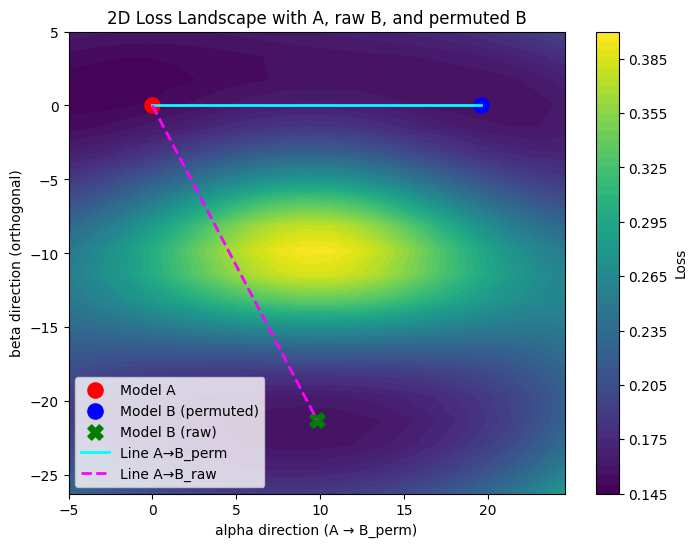

In [26]:
plt.figure(figsize=(8,6))

# Importing previous saved values
# loss_surface = np.load("loss_surface.npy")
# alphas = np.load("alphas.npy")
# betas = np.load("betas.npy")

CS = plt.contourf(alphas, betas, loss_surface.T, levels=50, cmap='viridis')
plt.colorbar(label="Loss")

# Plot Model A
plt.scatter(0, 0, c='red', s=120, marker='o', label='Model A')

# Plot permuted Model B (this is the aligned one)
plt.scatter(Bperm_x, Bperm_y, c='blue', s=120, marker='o', label='Model B (permuted)')

# Plot raw Model B (misaligned)
plt.scatter(Braw_x, Braw_y, c='green', s=120, marker='X', label='Model B (raw)')

# Draw line A → B_perm
plt.plot([0, Bperm_x], [0, Bperm_y],
         color='cyan', linestyle='-', linewidth=2,
         label='Line A→B_perm')

# Draw line A → B_raw
plt.plot([0, Braw_x], [0, Braw_y],
         color='magenta', linestyle='--', linewidth=2,
         label='Line A→B_raw')


plt.xlabel("alpha direction (A → B_perm)")
plt.ylabel("beta direction (orthogonal)")
plt.title("2D Loss Landscape with A, raw B, and permuted B")
plt.legend()

plt.show()